# ADA, Homework: A Cheating Scandal at St. Bob University 🎓

---

By the end of this homework, we expect you to be able to:
- Load data and handle data using pandas;
- Navigate the documentation of Python packages by yourself;
- Filter and tidy up noisy real-world datasets;
- Aggregate your data in different (and hopefully helpful) ways;
- Create meaningful visualizations to analyze the data;
- Communicate your findings in a clear and concise manner

**Important Dates.**
- Homework release: Wed 05 Nov, 2025
- Homework due: Wed 26 Nov, 2025, 23:59 (CET)

**Some rules**
- You are allowed to use any built-in Python library that comes with Anaconda. If you want to use an external library, you may do so, but must justify your choice.
- Make sure you use the data folder provided in the repository in read-only mode. (Or alternatively, be sure you don’t change any of the files.)
- Be sure to provide a concise textual description of your thought process, the assumptions you made, the solution you implemented, and explanations for your answers. A notebook that only has code cells will not suffice. To avoid confusion: use short comments for longer code answers.
- For questions containing the /Discuss:/ prefix, answer not with code, but with a textual explanation (in markdown).
- Back up any hypotheses and claims with data, since this is an important aspect of the course.
- Please write all your comments in English, and use meaningful variable names in your code. Your repo should have a single notebook (plus the required data files) in the master/main branch. If there are multiple notebooks present, we will not grade anything.
- We will not run your notebook for you! Rather, we will grade it as is, which means that only the results contained in your evaluated code cells will be considered, and we will not see the results in unevaluated code cells. Thus, be sure to hand in a fully-run and evaluated notebook. In order to check whether everything looks as intended, you can check the rendered notebook on the GitHub website once you have pushed your solution there.
- In continuation to the previous point, interactive plots, such as those generated using the ‘plotly’ package, should be strictly avoided! Make sure to print results and/or dataframes that confirm you have properly addressed the task.  
- In this homework, we have a task that asks to do clustering. Clustering algorithms will be covered in the lecture on unsupervised learning on Nov 12, 2025.


**A Note on using Language Models (LMs)**
If you try hard enough, you will likely get away with cheating. Fortunately, our job is not to police, but rather to educate! So, please consider the following:

Presumably, you are taking this course to learn something! LMs are not always right (they often fail in silly ways). This course should prepare you to detect when they are wrong!
Some of the TAs on this course literally published many works on detecting machine-generated text.

---
## Story:

In the sleepy university town of Bobwest, a scandal is rocking the community. St. Bob, a well-respected university known for its demanding curriculum, is facing allegations of widespread cheating since the introduction of ChatGPT! The basis of the allegations? A recent audit has found a significant year-over-year jump in the graduating class's grade point averages.

Eager to restore their reputation and facing immense public scrutiny, St. Bob’s dean of students, Ms. Sakota, has contacted EPFL’s renowned ADA staff to perform a rigorous analysis. The goal is to:

- Determine if the jump in GPAs is likely due to cheating. 🧐
- If so, identify the culprits. 🕵️
- Propose ways to prevent it from happening in the future. 💡

Ms. Sakota has commissioned the university’s IT team to prepare a number of files to aid in the analysis. Unfortunately, the university’s systems have undergone many changes over the years. She thus warns the ADA staff to send their best and brightest representatives.

### Files for this assignment
This assignment is divided into four tasks tasks, each of which should bring you a step closer to providing a recommendation to Ms. Sakota:

- **Task 1**: Preparing data the right way
- **Task 2**: Inspecting the data using statistical tests
- **Task 3**: Analyzing the problem through causal analysis
- **Task 4**: Catching cheaters!

```bash
📁 
│
├── 📄 2025_HW2.ipynb (the file you're currently reading!)
│
└── 📁 data
    ├── 📄 grades_dataset.csv
    └── 📄 grades_dataset_causal.csv
```


In [1]:
# imports
import random
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

#ignore FutureWarnings printed (generally happens when using groupby followed by apply)
import  warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Fix random seeds
np.random.seed(42)
random.seed(42)

## Task 1 (15 pts): Exploratory Data Analysis (EDA)
Oh no! It looks like not all data made it out in one piece... Before you're able
to do a proper analysis, you have to understand what type of data you are 
dealing with. This section is about learning to clean and understand your data.

In [2]:
df = pd.read_csv("data/grades_dataset.csv")

print(df.shape)
df.head()


(63568, 6)


,student_id,semester,year,class_id,grade,exam_type
0,5,Fall,2018,C0000,2.9,take-home
1,5,Fall,2018,C0000,2.2,take-home
2,7,Fall,2018,C0000,4.3,take-home
3,7,Fall,2018,C0000,3.3,take-home
4,9,Fall,2018,C0000,5.0,take-home


### Question 1.0 (6 pts)

**1.0.1 (3 pts)**: How many unique students are enrolling on average each year? Print year-wise counts.  
*Hint: students enroll in the Fall*

In [3]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

fall_students = df[df['semester'] == 'Fall'][['year','student_id']]

enrolled_students_per_year = (fall_students
                              .groupby('year')
                              .apply(lambda s: s['student_id'].nunique())
                              .rename('unique students count per year')
                              )

print(enrolled_students_per_year)

year
2018    298
2019    611
2020    628
2021    630
2022    610
2023    599
2024    601
Name: unique students count per year, dtype: int64


**1.0.2 (2 pts)**: How long does this degree program generally take to complete? (Round up to years)

In [4]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

"""
assumption : we compute the mean in semester. For example, we consider that if a student enrolled first in fall 2023 and has his last exam in fall 2024, his degree completion time 
will be counted as 3 semesters (1.5 years) when including it in the mean
"""
completion_time = (df
                   .groupby('student_id')
                   .apply(lambda s: len(s.drop_duplicates(subset= ['semester','year'])))
                   .agg('mean')/2)

print(f"this program generally takes {float(np.ceil(completion_time))} years to complete")



this program generally takes 2.0 years to complete


**1.0.3 (1 pts)**: How many classes does this program offer?

In [5]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

print(f"there are {df['class_id'].nunique()} distinct classes")

there are 20 distinct classes


### Question 1.1 (4 pts)  
Each student ID is supposed to be exactly 8 characters long. Inspect the data and solve the following tasks.

**1.1.1 (2 pts)**: Write code to make sure that each student ID is 8 characters long. When you run the cell, it will output 10 random student IDs which you can use to verify your code is working properly. These outputs will be used for grading also.    

*As examples, the student ID 123 should be converted to 00000123, 1234 to 00001234, and so on.*

In [6]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

df['student_id'] = df['student_id'].astype(str).apply(lambda s_id:s_id.zfill(8))
### DO NOT MODIFY THE FOLLOWING LINES ###
# randomly sample and print 10 student IDs
for _ in range(10):
    print(df['student_id'].sample(1).values[0])

00001036
00001044
00000497
00001789
00000253
00000467
00001351
00000864
00001344
00001304


**1.1.2. (2 pts)**: /Discuss/: what might have caused the issue?

In [7]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

When reading the `data/grades_dataset.csv` with `pd.read_csv`, the function detected and infered that the types of the `class_id` column was an int and converted it into an integer, removing the leading zeros. 

### Question 1.2 (5 pts)

**1.2.1a (2 pts)** Plot histogram of the grades distribution over time. (Note: You might need to convert the `grade` column to numeric type first. You can use `pd.to_numeric()` with `errors='coerce'`)

min grade : -1000000.0, max grade :  1000000.0


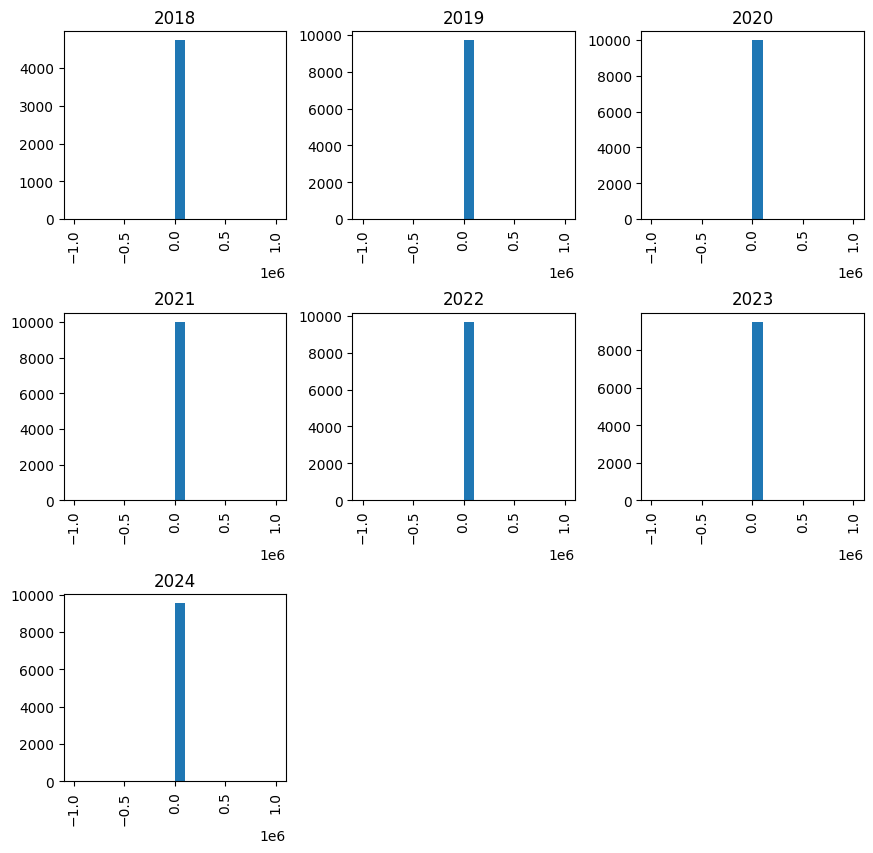

In [8]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

# drop grades that are non-numeric values
df = df.dropna(subset=['grade'])

df.hist(column="grade",by="year",bins=20,figsize=(10,10),layout=(3,3))
print(f"min grade : {df['grade'].min()}, max grade :  {df['grade'].max()}")


**1.2.1b (1 pts)** /Discuss/: Do you notice anything?

In [9]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

Our Histograms seem to show only one big line in the distribution. It is because there are just a few extreme grades having big values (e.g. max grade has value 100000 and min grade has value -100000), which stretch the x-axis to those extremes. Since almost every grade is distributed between 1 and 10, this makes the distrbution histograms look like a single line

**1.2.2 (2 pts)**: Please make sure the grades are between 1 and 10 and try again. Note: Any grades that are **not** in this range should be dropped.

10.0 1.0


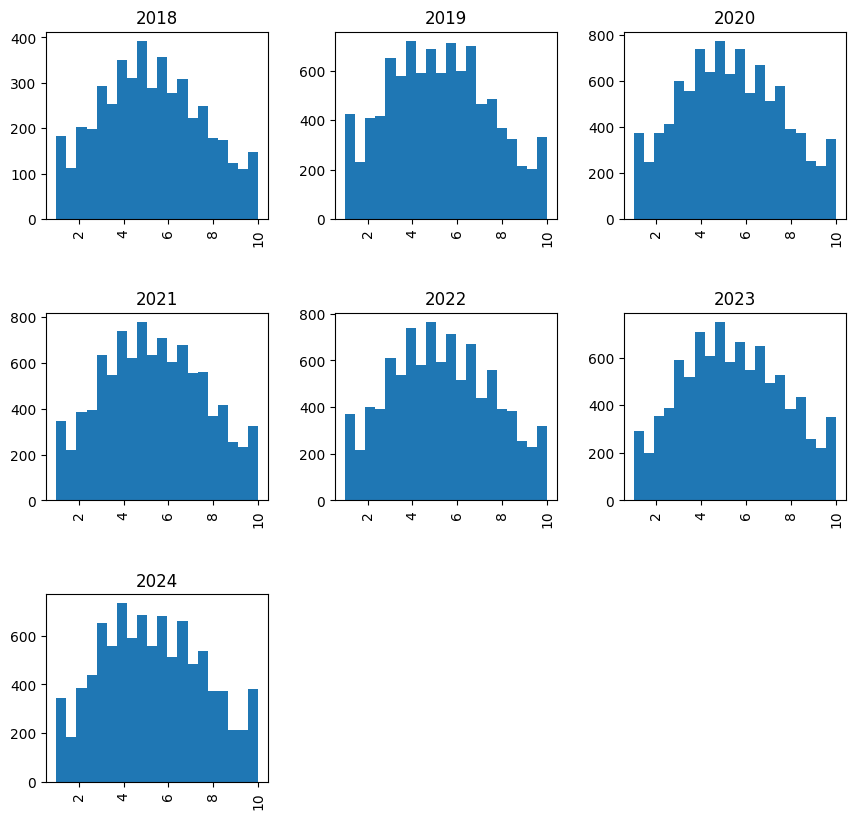

In [10]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

df = df[(df['grade'] >= 1) & (df['grade'] <= 10)]
df.hist(column="grade",by="year",bins=20,figsize=(10,10),layout=(3,3))

### DO NOT MODIFY THE FOLLOWING LINES ###
# print the maximum and minimum grade after grade range conversion
print(df['grade'].max(), df['grade'].min())




## Task 2 (30 pts): Statistical Analysis

### Question 2.1 (6 pts)
Let's take a look at the grades over time. For this,
1. plot the average grades for each year/semester with 95% "standard error" confidence intervals (CI)
2. in the same figure, plot the average take-home and in-person grades with 95% CI


**More details about the plot**:

- The output should be a single plot with three colors (one each for "All", "Take-Home", and "In-Person" grades).  
- The plot should have 14 points on x-axis (or xticks), i.e., 7 years (2018-2024) and 2 semesters (Fall, Spring) per year in chronological order (e.g., `2018Fall`, `2018Spring`, `2019Fall`, ..., `2024Spring`).   
- The y-axis should represent the average grades for each semester.   
- You must also include error bars (it is recommended to use `plt.errorbar()` and `plt.fill_between()` functions) representing the 95% confidence intervals for the average grades.   
- Finally, in the figure, it is recommended that the x-axis label, y-axis label, and the title should be `Year and Semester`, `Average Grade` and `Average Grades Over Time by Exam Type`, respectively.

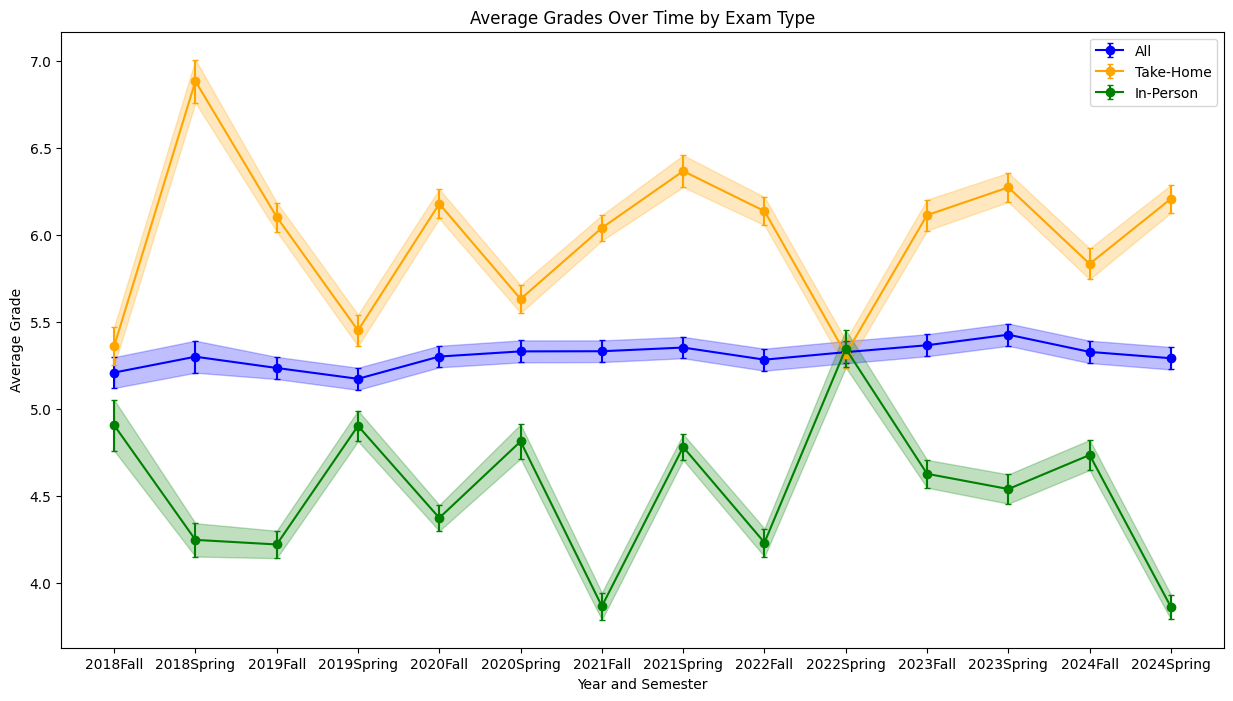

In [11]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

# associated z-score to obtain 95% confidence interval
ZSCORE = 1.96

# compute grades mean of a grade_serie and its corresponding standard error 
def compute_mean_se(grades_serie: pd.Series):
    n = grades_serie.count()
    grades_mean = grades_serie.mean()
    standard_error = grades_serie.std() / np.sqrt(n)
    return pd.Series({'grades_mean': grades_mean,'standard_error':standard_error})
    

df_by_semester = df.groupby(['year','semester'])

global_stats = df_by_semester.apply(lambda d: compute_mean_se(d['grade']))
takehome_stats = df_by_semester.apply(lambda d: compute_mean_se(d[d['exam_type'] == 'take-home']['grade']))
inperson_stats= df_by_semester.apply(lambda d: compute_mean_se(d[d['exam_type'] == 'in-person']['grade']))

x_names = [f"{year}{semester}" for year, semester in global_stats.index]



plt.figure(figsize=(15,8))

# plot the errorbar for each grade point
plt.errorbar(x = x_names, 
             y = global_stats['grades_mean'],
             yerr= ZSCORE *global_stats['standard_error'], 
             fmt='o-',capsize=2, label='All',color = 'blue')

plt.errorbar(x = x_names, 
             y= takehome_stats['grades_mean'], 
             yerr= ZSCORE * takehome_stats['standard_error'],
             fmt='o-',capsize=2, label='Take-Home',color = 'orange')
plt.errorbar(x = x_names, 
             y = inperson_stats['grades_mean'],
             yerr = ZSCORE * inperson_stats['standard_error'], 
             fmt='o-',capsize=2, label='In-Person',color = 'green')

# plot the confidence interval continuously on the graph
plt.fill_between(x = x_names,
                 y1 = global_stats['grades_mean'] - ZSCORE * global_stats['standard_error'],
                 y2 = global_stats['grades_mean'] + ZSCORE * global_stats['standard_error'],
                 color = 'blue',alpha = 0.25)
plt.fill_between(x = x_names,
                 y1 = takehome_stats['grades_mean'] - ZSCORE * takehome_stats['standard_error'],
                 y2 = takehome_stats['grades_mean'] + ZSCORE * takehome_stats['standard_error'],
                 color = 'orange',alpha = 0.25)
plt.fill_between(x = x_names,
                 y1 = inperson_stats['grades_mean'] - ZSCORE * inperson_stats['standard_error'],
                 y2 = inperson_stats['grades_mean'] + ZSCORE * inperson_stats['standard_error'],
                 color = 'green',alpha = 0.25)


plt.xlabel('Year and Semester')
plt.ylabel('Average Grade')
plt.title('Average Grades Over Time by Exam Type')
plt.legend()
plt.show()

### Question 2.2 (6 pts)

The plots from the previous question suggest that grades for take-home exams are consistently higher than for in-person exams. This observation is the cornerstone of the cheating allegation.

**2.2.1 (4 pts)**: Perform an appropriate statistical test to determine if the overall difference in mean grades between take-home and in-person exams is statistically significant.

In [12]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
# compute p-value from t-test which will be used in the interpretation section below


_,p_value = sp.stats.ttest_ind(takehome_stats['grades_mean'],inperson_stats['grades_mean'])
print(f"P-value is : {p_value}")

### DO NOT MODIFY THE FOLLOWING LINES ###
# Interpretation
# we assume there the variable p_value from the t-test is defined above
alpha = 0.05
if p_value < alpha:
    print(f"\nThe p-value is less than {alpha}, so we reject the null hypothesis.")
    print("There is a statistically significant difference in grades between take-home and in-person exams.")
else:
    print(f"\nThe p-value is greater than {alpha}, so we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in grades between take-home and in-person exams.")

P-value is : 1.7253368182917863e-09

The p-value is less than 0.05, so we reject the null hypothesis.
There is a statistically significant difference in grades between take-home and in-person exams.


**2.2.2 (1 pts)**: /Discuss/: Justify your choice of test.

In [13]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

We want to know if in-person and take home exams are sampled from the same or different distributions. We use ttest_ind because samples might be unrelated (it may happens that some students only had take-home exams or in-person exams)

**2.2.3 (1 pts)**: /Discuss/: Based on the result, what would be your preliminary conclusion to Ms. Sakota?

In [14]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

From The test we can statistically conclude that there is a significant difference between both results, however this is not enough to conclude that it is causally related to cheating. Some other factor could also be responsible for it, for example students could feel less stress at home, so we cannot give a definite answer right now.

### Question 2.3 (8 pts)
A senior professor suggests that the university's admission standards have been getting tougher, leading to a stronger student body over the years. This could be a confounding factor. Let's rigorously test the theory that the student body's academic performance has been changing year-over-year. We can use clustering to identify performance groups for each year and track their proportions over time.

1. Create a feature set by calculating the average grade for each student for each year they were enrolled.

2. Using this yearly performance data, apply the k-means clustering algorithm with k=3 to group the student-year records.

3. Analyze the cluster centers to label the groups as 'Low', 'Medium', and 'High' performers for any given year. **Print out the cluster centers along with their corresponding (above) labels.**

4. **Create a stacked bar plot showing the proportion of students belonging to each performance tier for each year. Print out the proportions for each year as well.**

**Note**: It is recommended to have the plot title as `Student Performance Composition by Year`, x-axis label as `Year`, and y-axis label as `Proportion of Students`.

cluster centers with their corresponding labels :  {4.169660996342982: 'Low', 6.589314521900945: 'High', 5.370381902048568: 'Medium'}
Proportions of grade between Low,Medium and High per year :
           Low    Medium      High
year                              
2018  0.342282  0.412752  0.244966
2019  0.360065  0.427169  0.212766
2020  0.318471  0.415605  0.265924
2021  0.285714  0.452381  0.261905
2022  0.306557  0.445902  0.247541
2023  0.277129  0.454090  0.268781
2024  0.294509  0.454243  0.251248


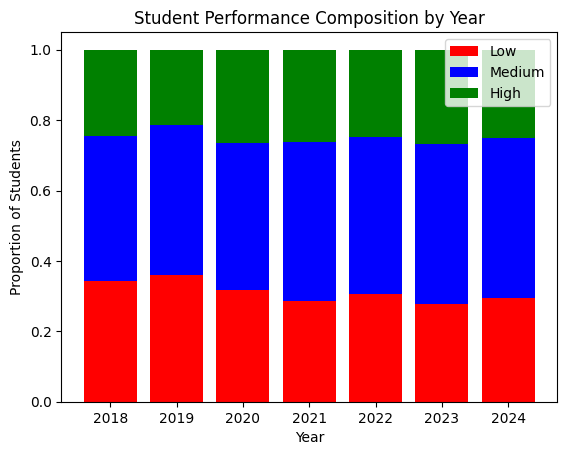

In [15]:
from sklearn.cluster import KMeans

### (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

# Subtask 1. Create features: average grade per student, per year
# Create a feature set by calculating the average grade for each student for each year they were enrolled.

#TODO check if we need to group by ('year',student_id') or ('student_id','year') because this change results for part 2.3 and 2.4
avg_grade_feature = df.groupby(['year','student_id']).apply(lambda d:d['grade'].mean()).reset_index()
avg_grade_feature.rename(columns={0:'avg_grade'},inplace=True)


### YOUR CODE BELOW ###

# Subtask 2. Use k-means on the yearly average grade
# Using this yearly performance data, apply the k-means clustering algorithm with k=3 to group the student-year records.

K = 3
kmeans = KMeans(n_clusters= K,random_state=42)

clusters = kmeans.fit_predict(X = avg_grade_feature[['avg_grade']])



### YOUR CODE BELOW ###

# Subtask 3. Analyze and label the clusters
# Analyze the cluster centers to label the groups as 'Low', 'Medium', and 'High' performers for any given year.
# Print out the cluster centers along with their corresponding (above) labels.

# centers for each cluster_id (index of the array = cluster_id)
centers = kmeans.cluster_centers_.reshape([K]).tolist()

group_labels = ['Low','Medium','High']
cluster_id_label = dict([(index,group_labels[ordinal]) for index,ordinal in enumerate(np.argsort(centers))])

print( "cluster centers with their corresponding labels : ",dict([(center,cluster_id_label[i]) for i,center in enumerate(centers)]))

avg_grade_feature['performance'] = [cluster_id_label[i] for i in clusters]


### YOUR CODE BELOW ###

# Subtask 4. Calculate proportions and create the stacked bar plot
# Create a stacked bar plot showing the proportion of students belonging to each performance tier for each year.
# Print out the proportions for each year as well.

x_years = sorted(int(year) for year in avg_grade_feature['year'].unique()) 
nb_grades_per_year = avg_grade_feature.groupby(['year'])['performance'].count()


low_grade_proportion  = avg_grade_feature[avg_grade_feature['performance'] == 'Low'].groupby(['year'])['student_id'].count() /nb_grades_per_year
medium_grade_proportion  = avg_grade_feature[avg_grade_feature['performance'] == 'Medium'].groupby(['year'])['student_id'].count() /nb_grades_per_year
high_grade_proportion  = avg_grade_feature[avg_grade_feature['performance'] == 'High'].groupby(['year'])['student_id'].count()   /nb_grades_per_year

proportions = pd.DataFrame({
    'Low' :low_grade_proportion,
    'Medium': medium_grade_proportion,
    'High': high_grade_proportion
})

print("Proportions of grade between Low,Medium and High per year :")
print(proportions)

plt.bar(x_years,low_grade_proportion,color = 'r')
plt.bar(x_years,medium_grade_proportion,bottom= low_grade_proportion,color = 'b')
plt.bar(x_years,high_grade_proportion,bottom = low_grade_proportion + medium_grade_proportion,color = 'g')

plt.title("Student Performance Composition by Year")
plt.xlabel("Year")
plt.ylabel("Proportion of Students")
plt.legend(group_labels)

### YOUR CODE BELOW ###

### Question 2.4 (5 pts)
The stacked bar plot from the previous question should suggest that the student body composition has been stable. While visual inspection is useful, a formal statistical test is more rigorous. Let's confirm if any apparent year-to-year change is statistically significant or likely due to random chance.

1. Focusing on the data for the last two years, 2023 and 2024, create a contingency table of student counts for each performance tier ('Low', 'Medium', 'High').

2. State the null (H0) and alternative (H1) hypotheses (in the markdown after this code cell) for a Chi-squared test of homogeneity on this data.

3. Perform the Chi-squared test. Report the Chi-squared statistic, the degrees of freedom, and the p-value.

4. Based on a significance level of α=0.05, what is your final conclusion?

**2.4.1 (4 pts)**: Code completion with conclusion about student body composition.

In [16]:
from scipy.stats import chi2_contingency

### (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

# 1. Filter for the last two years and create a contingency table
# Focusing on the data for the last two years, 2023 and 2024, create a contingency table of student counts for each performance tier ('Low', 'Medium', 'High').

avg_grade_feature = avg_grade_feature[avg_grade_feature['year'] >= 2023]
contingency_table = pd.crosstab(avg_grade_feature['year'],avg_grade_feature['performance'])

print(contingency_table)

### YOUR CODE BELOW ###

# 3. Perform the Chi-squared test
# Perform the Chi-squared test. Report the Chi-squared statistic, the degrees of freedom, and the p-value.

chi2_stat,p_value,dof,expected_freq = chi2_contingency(contingency_table)

print(f"\nChi-squared statistic : {chi2_stat}")
print(f"degrees of freedom: {dof}")
print(f"p-value: {p_value}")

### YOUR CODE BELOW ###

# 4. State the conclusion
# Based on a significance level of α=0.05, what is your final conclusion?
### YOUR CODE BELOW ###

alpha = 0.05
if p_value < alpha:
    print(f"\nThe p-value is less than {alpha}, so we reject the null hypothesis.")

else:
    print(f"\nThe p-value is greater than {alpha}, so we fail to reject the null hypothesis.")


performance  High  Low  Medium
year                          
2023          161  166     272
2024          151  177     273

Chi-squared statistic : 0.6717858949370294
degrees of freedom: 2
p-value: 0.7146996121236167

The p-value is greater than 0.05, so we fail to reject the null hypothesis.


**2.4.2 (1 pts)**: /Discuss/: State Hypotheses H0 and H1 you used for the Chi-squared test.

In [17]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###


Null hypothesis H0 : The student's distribution performance labeled as 'Low', 'Medium', 'High' is the same between year 2023 and 2024

Alternative hypothesis H1 : The student's distribution performance labeled as 'Low', 'Medium', 'High' differs between for year 2023 

Since we got a p-value of ~ 0.71, we cannot reject the Null hypothesis.

### Question 2.5 (5 pts)

The analysis so far has looked at the changing student body as the primary explanation for the grade trends.
An alternative hypothesis is that the issue isn't the exam format itself, but the classes that use them. A reasonable way to define a class's difficulty is by the average grade it awards.

**2.5.1 (1 pts)**: Calculate the overall average grade for each unique class_id. Additionally, sort the class_id based on their average grades in ascending (increasing) order and print them which will be used for grading.

In [18]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

avg_class_grade = (df
                   .groupby(['class_id'])['grade']
                   .mean()
                   .sort_values()
                   .rename('average_class_grades')
)


avg_class_grade

class_id
C0005    3.599731
C0007    3.660525
C0013    3.663899
C0003    3.748633
C0000    3.811896
C0018    3.859335
C0011    3.893795
C0016    3.906314
C0006    4.095179
C0002    4.198673
C0012    4.367767
C0019    4.564611
C0008    6.961434
C0014    7.182914
C0015    7.210656
C0004    7.304832
C0010    7.338963
C0001    7.389775
C0017    7.441622
C0009    7.451026
Name: average_class_grades, dtype: float64

**2.5.2 (2 pts)**: Create a histogram of these average class grades to visualize the distribution of class difficulties.

Text(0, 0.5, 'Class')

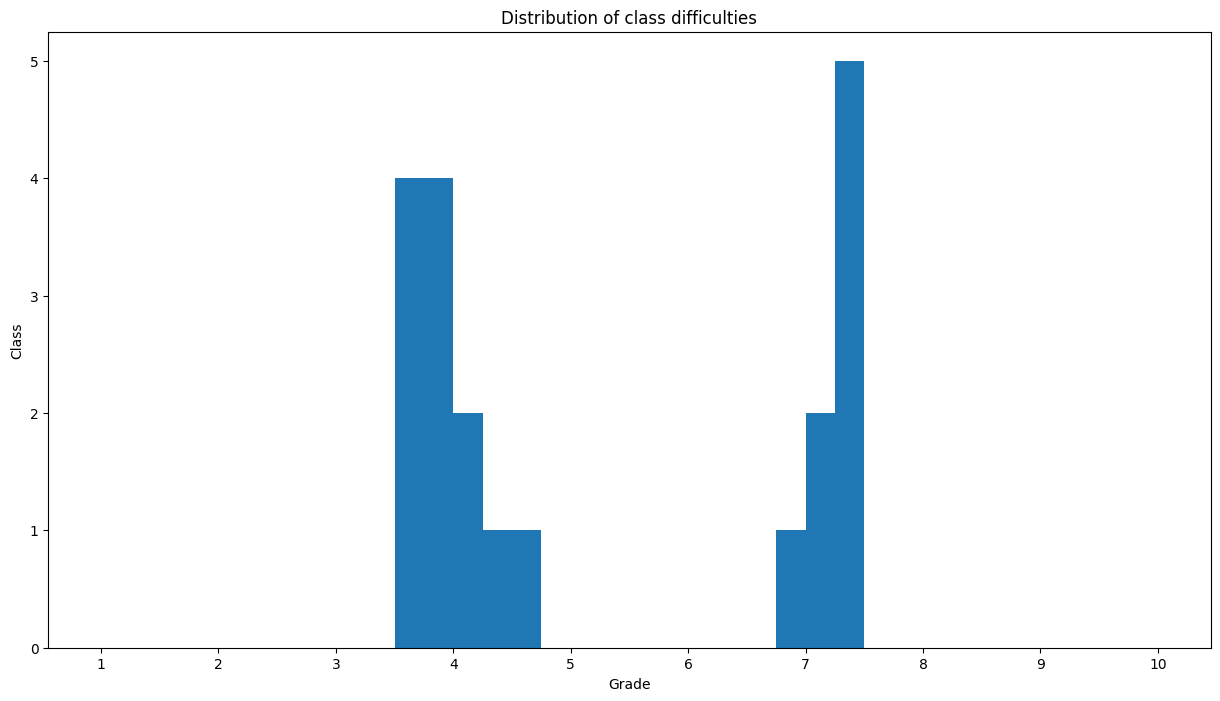

In [19]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

plt.figure(figsize=(15,8))

plt.xticks(np.arange(1,11,1))
plt.hist(avg_class_grade,bins = np.arange(1,10.25,0.25))
plt.title("Distribution of class difficulties")
plt.xlabel('Grade')
plt.ylabel('Class')

**2.5.3a (1 pts)**: Based on your analysis, identify the top 5 "easiest" (highest average grade) and top 5 "hardest" (lowest average grade) classes.

In [20]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
print('Top 5 easiest classes : ')
print(avg_class_grade.head(5).to_string() + '\n')

print('Top 5 hardest classes : ')
print(avg_class_grade.tail(5).to_string()+ '\n')

Top 5 easiest classes : 
class_id
C0005    3.599731
C0007    3.660525
C0013    3.663899
C0003    3.748633
C0000    3.811896

Top 5 hardest classes : 
class_id
C0004    7.304832
C0010    7.338963
C0001    7.389775
C0017    7.441622
C0009    7.451026



**2.5.3b (1 pts)**: /Discuss/: What does the distribution tell you about the curriculum at St. Bob?

In [21]:
### YOUR ANSWER BELOW (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###


We can distinguish 2 distincts groups in the distribution of class difficulties. There is 12 classes where the grade average is between 3.5 and 4.75 and 8 classes where the grade average is between 6.75 and 7.5. We have a group of "easy classes" and a group of "hard classes". So we can conclude that the curriculum at St.bob has either easy or hard classes.

## Task 3 (30 pts): Causal Analysis

In [22]:
df_causal = pd.read_csv("data/grades_dataset_causal.csv")

### Question 3.1 (6 pts)

Our statistical analysis has revealed a complex web of relationships. A simple t-test is not enough to determine causation. To reason about this properly, we need to build a causal model.

**3.1.1 (2 pts)**: Draw a Directed Acyclic Graph (DAG) that illustrates the plausible causal relationships between the following four variables:

- Student Ability (a student's intrinsic academic skill)
- Class Difficulty (how easy or hard a class is)
- Exam Type (in-person or take-home)
- Grade (the final outcome)

**Note**: It is recommended to create a DAG as the answer to this question (since you will need it for answering next questions). However, for this question (3.1.1), no points will be deducted if you only provide the directed edges in text format.

In [23]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###
### YOU CAN ALSO USE PYTHON PACKAGES AND CODE TO ANSWER THIS ###

# The code below has been used to generate the DAG graph image for 3.3.1 using networkx (which is not included in requirements.txt)

'''
import networkx as nx

pos = {
    'Student Ability': (-0.5, 0.5),
    'Class Difficulty': (0.5, 0.5), 
    'Exam Type': (0.5, -0.5),
    'Grade': (0, 0)
}
pos_labels = {node: (x+0.05, y) for node, (x, y) in pos.items()}

G = nx.DiGraph()
G.add_nodes_from(pos.keys())

edges = [
    ('Student Ability', 'Grade'),
    ('Class Difficulty', 'Grade'),  
    ('Exam Type', 'Grade'),
    ('Class Difficulty', 'Exam Type'),
    ('Student Ability', 'Class Difficulty')
]
G.add_edges_from(edges)
straight_edges = edges[:-1]
curved_edges = edges[-1:]

plt.figure(figsize=(7, 7))

nx.draw_networkx_nodes(G, pos, node_color='lightblue')
nx.draw_networkx_labels(G, pos_labels, font_size=10, font_weight='bold', horizontalalignment='left')
nx.draw_networkx_edges(G, pos, edgelist=straight_edges, arrows=True, arrowstyle='->')
nx.draw_networkx_edges(G, pos, edgelist=curved_edges, arrows=True, arrowstyle='->',connectionstyle="arc3,rad=-0.3")

plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

print("Directed edges in the DAG:")
for edge in edges:
    print(f"{edge[0]} → {edge[1]}")
'''

'\nimport networkx as nx\n\npos = {\n    \'Student Ability\': (-0.5, 0.5),\n    \'Class Difficulty\': (0.5, 0.5), \n    \'Exam Type\': (0.5, -0.5),\n    \'Grade\': (0, 0)\n}\npos_labels = {node: (x+0.05, y) for node, (x, y) in pos.items()}\n\nG = nx.DiGraph()\nG.add_nodes_from(pos.keys())\n\nedges = [\n    (\'Student Ability\', \'Grade\'),\n    (\'Class Difficulty\', \'Grade\'),  \n    (\'Exam Type\', \'Grade\'),\n    (\'Class Difficulty\', \'Exam Type\'),\n    (\'Student Ability\', \'Class Difficulty\')\n]\nG.add_edges_from(edges)\nstraight_edges = edges[:-1]\ncurved_edges = edges[-1:]\n\nplt.figure(figsize=(7, 7))\n\nnx.draw_networkx_nodes(G, pos, node_color=\'lightblue\')\nnx.draw_networkx_labels(G, pos_labels, font_size=10, font_weight=\'bold\', horizontalalignment=\'left\')\nnx.draw_networkx_edges(G, pos, edgelist=straight_edges, arrows=True, arrowstyle=\'->\')\nnx.draw_networkx_edges(G, pos, edgelist=curved_edges, arrows=True, arrowstyle=\'->\',connectionstyle="arc3,rad=-0.3")\n\

(-0.5, 689.5, 689.5, -0.5)

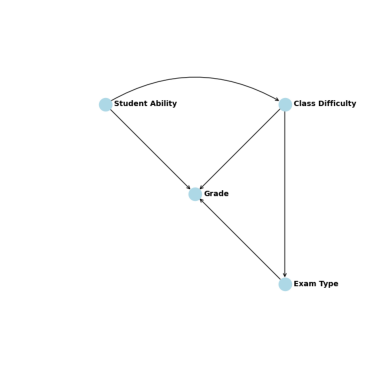

In [24]:
plt.imshow(plt.imread('dag.png'))
plt.axis('off')

**3.1.2 (2 pts)**: /Discuss/: For each arrow (directed edge) in your graph, write a one-sentence justification for its existence and direction. For example, "An arrow from Student Ability to Grade represents that a student's ability directly affects the grade they receive."

In [25]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

* An arrow from Student Ability to Grade represents that a student's ability directly affects the grade they may receive (a more capable student might achieve a higher grade even if the other factors are the same because of their background).
* An arrow from Class Difficulty to Grade represents that the difficulty level of the class impacts the grade (same student with the same exam type might receive a different grade if the class is more difficult).
* An arrow from Exam Type to Grade represents that the type of exam influences the grade (same student with the same class difficulty might receive a different grade if the exam type is different).
* An arrow from Class Difficulty to Exam Type represents that the difficulty of the class affects the type of exam given (for instance, harder classes might be more likely to have in-person exams to prevent cheating).
* An arrow from Student Ability to Class Difficulty represents that more capable students might choose or be placed in more difficult classes.

**3.1.3 (2 pts)**: /Discuss/: Based on your DAG, identify any confounding variables that might distort the simple relationship between Exam Type and Grade. Explain how your diagram illustrates this confounding.

In [26]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

1. **Class Difficulty** is a confounding variable because it has arrows pointing to both Exam Type and Grade, which creates a backdoor path: Exam Type <- Class Difficulty -> Grade. This means that the observed association between exam type and grade could be partially explained by class difficulty rather than exam type itself. For example, if easier classes tend to use take-home exams more often, then higher grades in take-home exams might be due to the classes being easier, not because the exam format allows for better performance.

2. **Student Ability** is another confounding variable, but it affects the relationship indirectly through Class Difficulty. The confounding path is: Exam Type <- Class Difficulty <- Student Ability -> Grade. This means that more capable students might select harder classes, which in turn might be more likely to use in-person exams, creating a spurious association between exam type and grade.


### Question 3.2 (5 pts)

Your DAG likely shows that a student's ability is a major confounder. We can control for this by comparing a student against themselves. A paired t-test is an excellent tool for this.

**3.2.1 (2 pts)**: 
1. Identify all students who have taken at least one of each exam type during their studies. 
2. For this subset of students, calculate each student's average grade on take-home exams and their average grade on in-person exams. 

Since for the paired t-test we require students who have an average grade for BOTH exam types, your task is to **print the number of students who have taken both exam types**, which will be used for grading.

In [27]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
# At the end, print the number of students who have taken both exam 

all_exam_type = set(df_causal['exam_type'].unique())

students_all_exam_types_bool = df_causal.groupby(['student_id']).apply(lambda d : all_exam_type.issubset(set(d['exam_type'])))
all_exam_type_student_ids = students_all_exam_types_bool[students_all_exam_types_bool == True].index

all_exam_type_students = df_causal[df_causal['student_id'].isin(all_exam_type_student_ids)]

print(f"number of students who took both exam types : {all_exam_type_students['student_id'].nunique()}")

avg_grades = all_exam_type_students.groupby(['student_id','exam_type']).apply(lambda d: d['grade'].mean()).unstack()



number of students who took both exam types : 2448


**3.2.2a (1 pts)**: Perform a paired t-test on these two sets of average grades and print the T-statistic and P-value. 

In [28]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
t_statistic,p_value = sp.stats.ttest_rel(avg_grades['in-person'],avg_grades['take-home'])
print(f"T statistic is : {t_statistic}")
print(f"P-value is : {p_value}")

### DO NOT MODIFY THE FOLLOWING LINES ###
# Interpretation
# we assume there the variable p_value from the t-test is defined above
alpha = 0.05
if p_value < alpha:
    print(f"\nThe p-value is less than {alpha}, so we reject the null hypothesis.")
else:
    print(f"\nThe p-value is greater than {alpha}, so we fail to reject the null hypothesis.")



T statistic is : -62.41703313132703
P-value is : 0.0

The p-value is less than 0.05, so we reject the null hypothesis.


**3.2.2b (2 pts)**: /Discuss/: State your null and alternative hypotheses. 

In [29]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

H0 - null hypothesis The distribution of in-person grades and take-home grades comes from the same distribution

H1 - The distributions are different for in-person and take-home exam grades.

The P-value is so small that it underflows, and is set to 0 (very strong statistically), the t-statistic of -62 means that on average take-away exams have a much higher grade, then in-person, and there is almost zero chance that this is due to chance.

(note that we use ttest_rel because the samples are related. Since we filtered all of the students that took both exam type, we know that each sample in avg_grades['in-person'] has a related sample in avg_grades['take-home'])

### Question 3.3 (6 pts)

The paired t-test in the previous question was a great step, as it controlled for baseline differences in Student Ability by comparing each student to themselves. However, there's another potential confounding factor we haven't addressed: Class Difficulty. What if students tend to get take-home exams in easier classes? If so, the higher grades might be due to the class being easy, not the exam type.

**3.3.1 (5 pts)**:
To isolate the true effect of the exam type, we need to make our comparisons even fairer by controlling for both student ability (you can ignore the "Medium" performers, and consider "High" as High-ability students and "Low" for Low-ability students)  and class difficulty at the same time.

1. Using the `df_causal` dataset, group your data into four distinct categories based on student ability and class difficulty:

- High-ability students in Easy classes
- Low-ability students in Easy classes
- High-ability students in Hard classes
- Low-ability students in Hard classes

2. Create a 1x2 grid of subplots to compare these groups.

- The left subplot should show the data for Easy classes and the right for Hard classes.
- On the x-axis of each subplot, show the results for 'Low' and 'High' ability students.
- Use bars to represent the average grade for both 'in-person' and 'take-home' exams within each category.

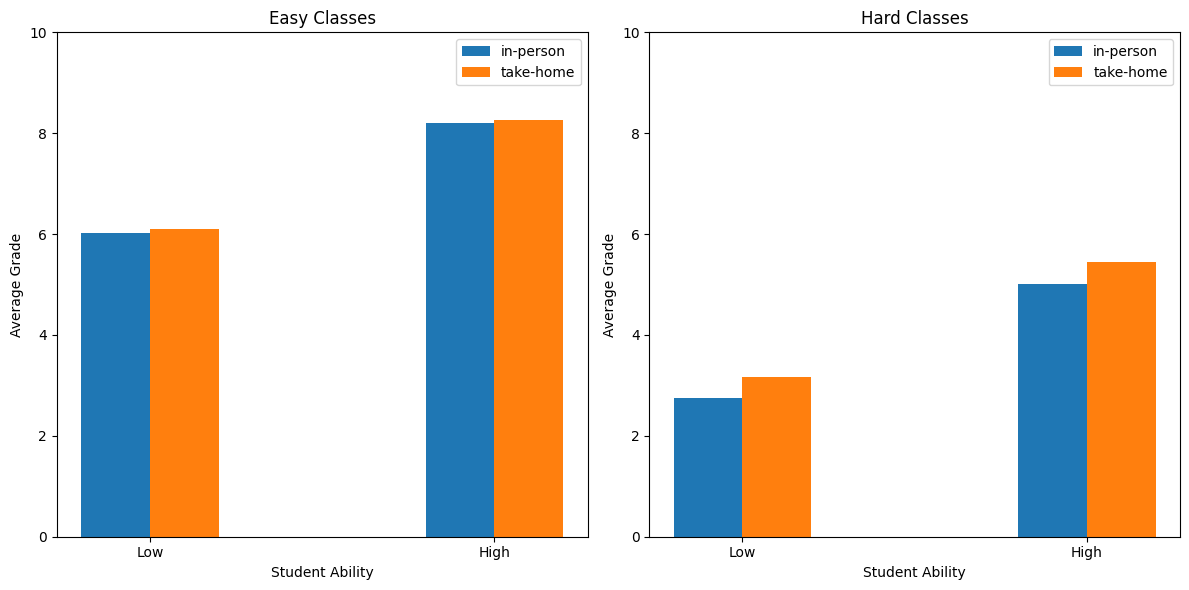

In [30]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###

def compute_mean_grade(df_subset: pd.DataFrame, exam_type: str) -> float:
    return df_subset[df_subset['exam_type'] == exam_type]['grade'].mean()

high_ability_students_easy_classes = df_causal[(df_causal['tier_kmeans'] == 'High') & (df_causal['difficulty_tier'] == 'Easy')]
low_ability_students_easy_classes = df_causal[(df_causal['tier_kmeans'] == 'Low') & (df_causal['difficulty_tier'] == 'Easy')]
high_ability_students_hard_classes = df_causal[(df_causal['tier_kmeans'] == 'High') & (df_causal['difficulty_tier'] == 'Hard')]
low_ability_students_hard_classes = df_causal[(df_causal['tier_kmeans'] == 'Low') & (df_causal['difficulty_tier'] == 'Hard')]

easy_high_inperson = compute_mean_grade(high_ability_students_easy_classes, 'in-person')
easy_high_takehome = compute_mean_grade(high_ability_students_easy_classes, 'take-home')
easy_low_inperson = compute_mean_grade(low_ability_students_easy_classes, 'in-person')
easy_low_takehome = compute_mean_grade(low_ability_students_easy_classes, 'take-home')
hard_high_inperson = compute_mean_grade(high_ability_students_hard_classes, 'in-person')
hard_high_takehome = compute_mean_grade(high_ability_students_hard_classes, 'take-home')
hard_low_inperson = compute_mean_grade(low_ability_students_hard_classes, 'in-person')
hard_low_takehome = compute_mean_grade(low_ability_students_hard_classes, 'take-home')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
x_pos = [0, 1]
width = 0.2

axs[0].bar([x - width/2 for x in x_pos], [easy_low_inperson, easy_high_inperson], width, label='in-person')
axs[0].bar([x + width/2 for x in x_pos], [easy_low_takehome, easy_high_takehome], width, label='take-home')
axs[0].set_title('Easy Classes')
axs[1].bar([x - width/2 for x in x_pos], [hard_low_inperson, hard_high_inperson], width, label='in-person')
axs[1].bar([x + width/2 for x in x_pos], [hard_low_takehome, hard_high_takehome], width, label='take-home')
axs[1].set_title('Hard Classes')

for ax in axs:
    ax.set_xlabel('Student Ability')
    ax.set_ylabel('Average Grade')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Low', 'High'])
    ax.legend()
    ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()

**3.3.2 (1 pts)** /Discuss/: Analyze your plot. After controlling for both factors, what is the difference in average grades between exam types within each of the four subgroups?

In [31]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###
easy_high_diff = easy_high_takehome - easy_high_inperson
easy_low_diff = easy_low_takehome - easy_low_inperson
hard_high_diff = hard_high_takehome - hard_high_inperson
hard_low_diff = hard_low_takehome - hard_low_inperson

print(f"Difference in average grades for high ability students in easy classes (take-home - in-person): {easy_high_diff}")
print(f"Difference in average grades for low ability students in easy classes (take-home - in-person): {easy_low_diff}")
print(f"Difference in average grades for high ability students in hard classes (take-home - in-person): {hard_high_diff}")
print(f"Difference in average grades for low ability students in hard classes (take-home - in-person): {hard_low_diff}")

Difference in average grades for high ability students in easy classes (take-home - in-person): 0.06646457990115273
Difference in average grades for low ability students in easy classes (take-home - in-person): 0.08224150192393509
Difference in average grades for high ability students in hard classes (take-home - in-person): 0.44357281444269514
Difference in average grades for low ability students in hard classes (take-home - in-person): 0.4082575942742066


There is no signficiant difference of average grades between take-home exams and in-person exams. However we can notice that the the difference is slightly more higher for hard classes.

### Question 3.4 (9 pts)

Another way to untangle these effects is to use a predictive model. A decision tree can show us which factors are most important for predicting a student's grade, which can help confirm our causal conclusion.

**3.4.1 (6 pts)**  

**3.4.1a**: Prepare your data: Create a dataset with Grade as the target variable. The features should be:

- A numerical feature for Student Ability (use each student's overall average grade).

- A numerical feature for Class Difficulty (use each class's overall average grade).

- A numerical feature for Exam Type (convert 'in-person' to 0 and 'take-home' to 1).

In [32]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

### YOUR CODE BELOW ###
student_ability = df_causal.groupby('student_id')['grade'].mean()
class_difficulty = df_causal.groupby('class_id')['grade'].mean()
df_causal['student_ability'] = df_causal['student_id'].map(student_ability)
df_causal['class_difficulty'] = df_causal['class_id'].map(class_difficulty)
df_causal['exam_type_numeric'] = df_causal['exam_type'].map({'in-person': 0, 'take-home': 1})

features = df_causal[['student_ability', 'class_difficulty', 'exam_type_numeric']]
target = df_causal['grade']

features.head()


,student_ability,class_difficulty,exam_type_numeric
0,4.16875,4.044568,1
1,4.16875,4.044568,1
2,4.82500,4.044568,1
3,4.82500,4.044568,1
4,4.75625,4.044568,1


**3.4.1b**: Train a DecisionTreeRegressor on this data. To keep the model easy to interpret, set the max_depth to 3. **Visualize the resulting tree** with `plot_tree`.

[Text(0.5, 0.875, 'class_difficulty <= 5.282\nsquared_error = 5.101\nsamples = 72576\nvalue = 5.531'),
 Text(0.25, 0.625, 'student_ability <= 5.63\nsquared_error = 2.327\nsamples = 33362\nvalue = 3.735'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'student_ability <= 4.914\nsquared_error = 1.594\nsamples = 17660\nvalue = 2.974'),
 Text(0.0625, 0.125, 'squared_error = 1.298\nsamples = 8210\nvalue = 2.523'),
 Text(0.1875, 0.125, 'squared_error = 1.519\nsamples = 9450\nvalue = 3.366'),
 Text(0.375, 0.375, 'student_ability <= 6.383\nsquared_error = 1.769\nsamples = 15702\nvalue = 4.59'),
 Text(0.3125, 0.125, 'squared_error = 1.642\nsamples = 9314\nvalue = 4.231'),
 Text(0.4375, 0.125, 'squared_error = 1.494\nsamples = 6388\nvalue = 5.113'),
 Text(0.75, 0.625, 'student_ability <= 5.683\nsquared_error = 2.382\nsamples = 39214\nvalue = 7.059'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'student_ability <= 4.82\nsquared_error = 1.818\nsamples = 23402\nvalue = 6.423'),
 Text(0.5

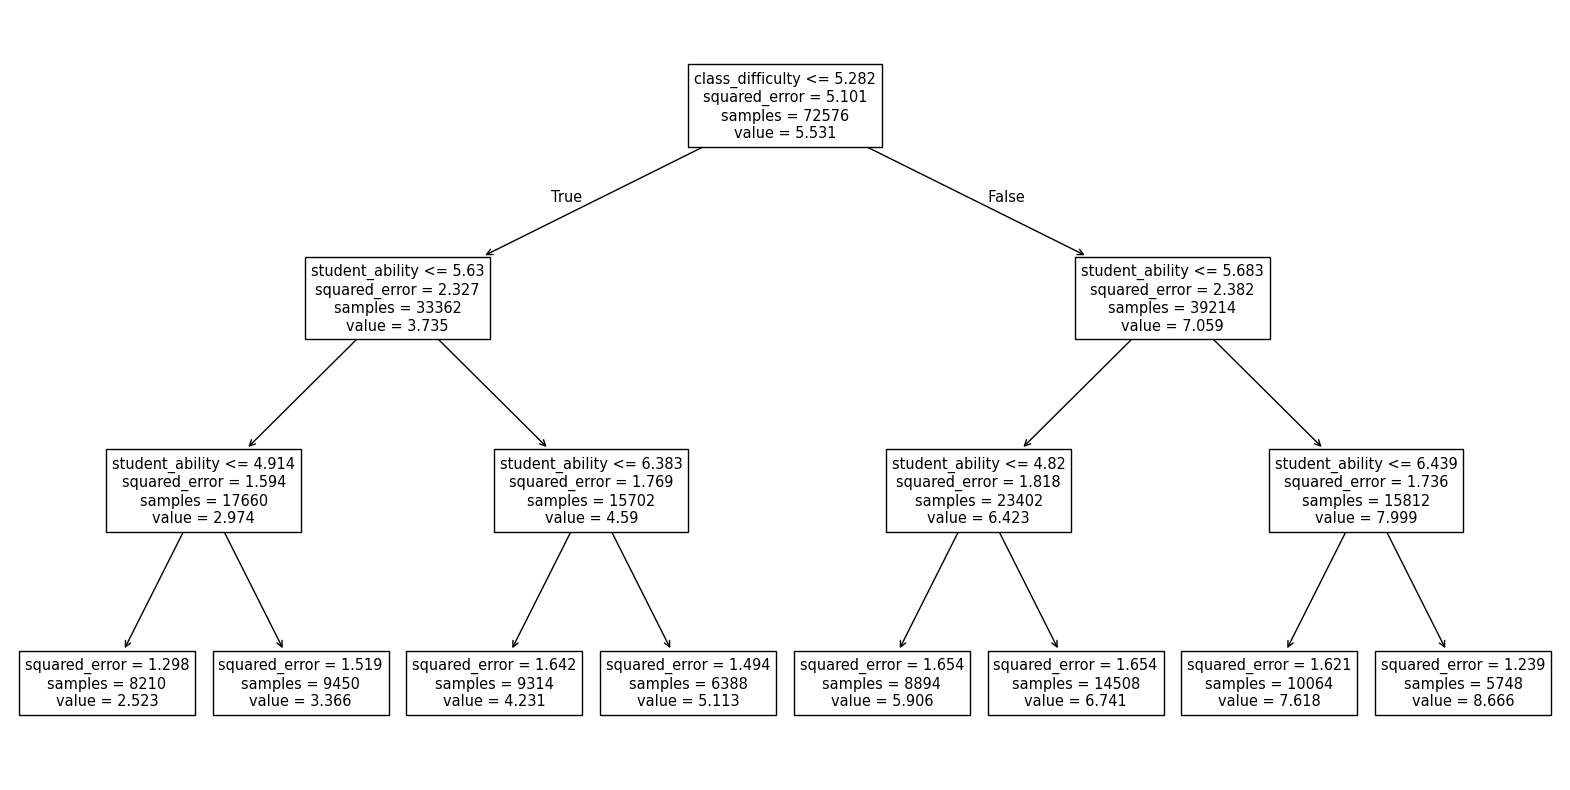

In [33]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
decision_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
decision_tree.fit(features, target)
plt.figure(figsize=(20,10))
plot_tree(decision_tree, feature_names=features.columns)

**3.4.2 (1 pts)**: Print the `feature_importances_` of the trained model in ascending (increasing) order.

In [34]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
feature_importance_pairs = list(zip(features.columns, decision_tree.feature_importances_))
feature_importance_pairs.sort(key=lambda x: x[1])

for feature, importance in feature_importance_pairs:
    print(f"Feature: {feature}, Importance: {importance}")

Feature: exam_type_numeric, Importance: 0.0
Feature: student_ability, Importance: 0.2287064112386911
Feature: class_difficulty, Importance: 0.7712935887613089


**3.4.3 (2 pts)**:
/Discuss:/ 
1. According to the model, which features are most important for predicting a grade? 
2. How does the importance of Exam Type compare to the others? 
3. How does this support your conclusion from the stratified analysis?

In [35]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

1. The most important features for predicting a grade are Class Difficulty and Student Ability, with Exam Type being the least important.
2. Exam Type has a 0 importance score, indicating it does not contribute to the model's predictions.
3. In our graph in part 3.3.1. We can observe that average grades is significatively lower for hard classes (~2.5-3pts lower) than for easy classes. Then we can observe that average grades for high ability students is ~25% higher in easy class and ~50% higher in hard class meaning that the effect of the student ability on the average grades depends on the class difficulty. Which means that class difficulty has more importance on the grade average than the student ability. We can also conclude that there is no significant difference in grade average when considering the exam_type feature (see 3.3.2)

### Question 3.5 (4 pts)
/Discuss/: This is the final step in your investigation for Ms. Sakota. What is your ultimate conclusion now? Does the exam type itself cause higher grades, or was the initial observation misleading due to confounding variables? Explain your reasoning.

In [36]:
### YOUR ANSWER (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

According to our analyses we can conclude that exam type doesn't affect heavily the grades, ir gives a slight boost, but its small and the disparity in results where much more driven by the confounding factors (student score and class difficulty), not by the exam type  itself.

## Task 4 (10 pts): Finding Potential Cheaters

But wait..., there could be some students who might be mis-using take-home exams to cheat. We will compare the increase in the average grades of students who took both types of exams (in-person and take-home) in 2022 and 2023, since ChatGPT was released in late 2022.

In [37]:
df_causal = pd.read_csv("data/grades_dataset_causal.csv")

**4.1 (6 pts)**
1. Identify all students who took both types of exams in both 2022 and 2023 in `df_causal`.
2. For each of these students, calculate their average grade for in-person exams and take-home exams for both years.
3. For each student, compute the change in their average take-home exam grades from 2022 to 2023. Similarly, we also compute the change for in-person grades. We name them as `delta_takehome` and `delta_inperson` respectively.
4. Find the difference between `delta_takehome` and `delta_inperson` for each student. We call it as `delta_diff`.
4. Find the mean and standard deviation of `delta_diff` across all identified students.
5. Select 'outliers' as those students whose `delta_diff` is more than 2 standard deviations above the mean. Print the student IDs of these outliers as a list.

**Note**: When you run the cell, ensure that it will output the list of student IDs flagged as potential cheaters, which will be used for grading.

In [38]:
### YOUR CODE BELOW (THE **OUTPUT** OF THIS CELL WILL BE USED FOR EVALUATION) ###
# Ensure that this cell outputs the student IDs of the outliers as a list of integer IDs

# 1. Identify all students who took both types of exams in both 2022 and 2023 in `df_causal`.
df_causal_2022_2023 = df_causal[df_causal['year'].isin([2022, 2023])]
all_exam_type_2 = set(df_causal_2022_2023['exam_type'].unique())
students_all_exam_types_bool_2 = df_causal_2022_2023.groupby(['student_id']).apply(lambda d : all_exam_type_2.issubset(set(d['exam_type'])))
all_exam_type_student_ids_2 = students_all_exam_types_bool_2[students_all_exam_types_bool_2 == True].index
all_exam_type_students_2 = df_causal_2022_2023[df_causal_2022_2023['student_id'].isin(all_exam_type_student_ids_2)]

## 2. For each of these students, calculate their average grade for in-person exams and take-home exams for both years.
all_exam_type_students_2022 = all_exam_type_students_2[all_exam_type_students_2['year'] == 2022]
avg_grades_2022 = all_exam_type_students_2022.groupby(['student_id','exam_type']).apply(lambda d: d['grade'].mean()).unstack()

all_exam_type_students_2023 = all_exam_type_students_2[all_exam_type_students_2['year'] == 2023]
avg_grades_2023 = all_exam_type_students_2023.groupby(['student_id','exam_type']).apply(lambda d: d['grade'].mean()).unstack()

## 3. For each student, compute the change in their average take-home exam grades from 2022 to 2023. Similarly, we also compute the change for in-person grades. We name them as `delta_takehome` and `delta_inperson` respectively.
avg_grades_2022 = avg_grades_2022.rename(columns={'in-person': 'inperson_2022', 'take-home': 'takehome_2022'})
avg_grades_2023 = avg_grades_2023.rename(columns={'in-person': 'inperson_2023', 'take-home': 'takehome_2023'})
avg_grades_with_deltas = avg_grades_2022.join(avg_grades_2023, how='inner')
avg_grades_with_deltas['delta_takehome'] = avg_grades_with_deltas['takehome_2023'] - avg_grades_with_deltas['takehome_2022']
avg_grades_with_deltas['delta_inperson'] = avg_grades_with_deltas['inperson_2023'] - avg_grades_with_deltas['inperson_2022']

## 4. Find the difference between `delta_takehome` and `delta_inperson` for each student. We call it as `delta_diff`.
avg_grades_with_deltas['delta_diff'] = avg_grades_with_deltas['delta_takehome'] - avg_grades_with_deltas['delta_inperson']

## 4. Find the mean and standard deviation of `delta_diff` across all identified students.
avg_grades_with_deltas['delta_diff_mean'] = avg_grades_with_deltas['delta_diff'].mean()
avg_grades_with_deltas['delta_diff_std'] = avg_grades_with_deltas['delta_diff'].std()

## 5. Select 'outliers' as those students whose `delta_diff` is more than 2 standard deviations above the mean. Print the student IDs of these outliers as a list.
outlier_condition = avg_grades_with_deltas['delta_diff'] > (avg_grades_with_deltas['delta_diff_mean'] + 2 * avg_grades_with_deltas['delta_diff_std'])
outlier_student_ids = avg_grades_with_deltas[outlier_condition].index.tolist()
print("outlier student_ids are : ")
print(outlier_student_ids)


outlier student_ids are : 
[1398, 1400, 1413, 1505, 1588, 1622, 1653, 1660, 1703]


**4.2.1 (2 pts)**:
- /Discuss/: Assume we consider the outlier students as potential cheaters. Why could this approach fail to identify cheaters? Suggest one problem with the above approach.

In [39]:
### YOUR ANSWER HERE (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

One problem of the biggest problem of this approach is that we assume that cheaters only started cheating in 2023, meaning that their cheating showed a great difference in exam results, however even without chatgpt, they could cheat in many ways, especially for at home exams, in that case the difference would be relatively small and won't appear on the radars.

**4.2.2 (2 pts)**:
- /Discuss/: Suggest one improvement to make this approach more robust.

In [40]:
### YOUR ANSWER HERE (CREATE A NEW MARKDOWN CELL BELOW TO ANSWER) ###

Since the program takes on average 2 years to complete we cannot suggest increasing the observation length, as such we can try to look not only at the difference in grades, but also the curriculum of the student, it may be expected that the students average grade skyrockets if he took many easy classes in 2023 and only a few in 2022, or vice versa. This could help remove/explain some outliers by their curriculum choices.